In [11]:
pip install scikit-learn pandas numpy matplotlib seaborn

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [14]:
# Cell 3: Upload and load the CSV file
# A file picker will appear — select your diabetes.csv from your computer

from google.colab import files
import io

uploaded = files.upload()  # ← A button will appear, click it and upload diabetes.csv

# Load it directly from the uploaded file
df = pd.read_csv(io.BytesIO(uploaded['diabetes.csv']))

print("✅ File loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving diabetes.csv to diabetes.csv
✅ File loaded successfully!
Shape of dataset: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
# Each column is a medical measurement

print("Column names and data types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Column names and data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:

# Actual null values
print("Null values in each column:")
print(df.isnull().sum())

# In this dataset, 0s in medical columns are actually missing values
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nZero counts (likely missing values) in medical columns:")
print((df[cols_with_zeros] == 0).sum())

# Class balance
print("\nOutcome distribution (0 = No Diabetes, 1 = Diabetes):")
print(df['Outcome'].value_counts())
print(f"\nDiabetes rate: {df['Outcome'].mean()*100:.1f}%")

Null values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero counts (likely missing values) in medical columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Outcome distribution (0 = No Diabetes, 1 = Diabetes):
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


In [17]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)
    print(f"Replaced 0s in '{col}' with median = {median_val:.1f}")

Replaced 0s in 'Glucose' with median = 117.0
Replaced 0s in 'BloodPressure' with median = 72.0
Replaced 0s in 'SkinThickness' with median = 29.0
Replaced 0s in 'Insulin' with median = 125.0
Replaced 0s in 'BMI' with median = 32.3


In [18]:
X = df.drop('Outcome', axis=1)   # All columns except Outcome
y = df['Outcome']                 # The column we want to predict

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Feature matrix X shape: (768, 8)
Target vector y shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [20]:

# Run this multiple times and notice the accuracy keeps changing!

from sklearn.model_selection import train_test_split

scores_list = []
model = LogisticRegression(max_iter=1000)

for seed in range(10):  # Try 10 different random splits
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    # Scale features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)
    acc = model.score(X_test_s, y_test)
    scores_list.append(acc)

print("Accuracy with 10 different random splits:")
for i, s in enumerate(scores_list):
    print(f"  Split {i+1}: {s:.4f}")

print(f"\nMin: {min(scores_list):.4f}  |  Max: {max(scores_list):.4f}")
print(f"Range = {max(scores_list) - min(scores_list):.4f}")
print("\n⚠️  The result changes every time! This is unreliable.")
print("✅ Solution: Use K-Fold Cross-Validation to get a stable estimate.")

Accuracy with 10 different random splits:
  Split 1: 0.8117
  Split 2: 0.7727
  Split 3: 0.7662
  Split 4: 0.7403
  Split 5: 0.7987
  Split 6: 0.8117
  Split 7: 0.7922
  Split 8: 0.7727
  Split 9: 0.7468
  Split 10: 0.7468

Min: 0.7403  |  Max: 0.8117
Range = 0.0714

⚠️  The result changes every time! This is unreliable.
✅ Solution: Use K-Fold Cross-Validation to get a stable estimate.


In [21]:
#  Apply Stratified K-Fold Cross-Validation
# Stratified = each fold keeps the same ratio of 0s and 1s as the full dataset
# This matters because our classes are imbalanced (65% vs 35%)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We use a Pipeline so scaling happens inside each fold (correct way!)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

print("Stratified K-Fold (K=5) Results — Logistic Regression")
print("-" * 45)
for i, s in enumerate(scores):
    print(f"  Fold {i+1}: {s:.4f}")

print(f"\n  Mean Accuracy : {scores.mean():.4f}")
print(f"  Std Deviation : {scores.std():.4f}")
print(f"  95% Confidence: {scores.mean():.4f} ± {1.96 * scores.std():.4f}")

Stratified K-Fold (K=5) Results — Logistic Regression
---------------------------------------------
  Fold 1: 0.7727
  Fold 2: 0.7987
  Fold 3: 0.7792
  Fold 4: 0.7516
  Fold 5: 0.7647

  Mean Accuracy : 0.7734
  Std Deviation : 0.0156
  95% Confidence: 0.7734 ± 0.0307


In [23]:
#  Test 3 beginner-friendly models using the same K-Fold setup
# Logistic Regression, Decision Tree, K-Nearest Neighbors

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5)
}

results = {}

print(f"{'Model':<25} {'Fold 1':>7} {'Fold 2':>7} {'Fold 3':>7} {'Fold 4':>7} {'Fold 5':>7} {'Mean':>8} {'Std':>7}")
print("-" * 80)

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    fold_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    results[name] = fold_scores

    fold_str = "  ".join([f"{s:.4f}" for s in fold_scores])
    print(f"{name:<25} {fold_str}  {fold_scores.mean():.4f}  {fold_scores.std():.4f}")

Model                      Fold 1  Fold 2  Fold 3  Fold 4  Fold 5     Mean     Std
--------------------------------------------------------------------------------
Logistic Regression       0.7727  0.7987  0.7792  0.7516  0.7647  0.7734  0.0156
Decision Tree             0.7662  0.7273  0.7403  0.7320  0.6797  0.7291  0.0281
KNN (k=5)                 0.7338  0.7468  0.7468  0.7255  0.6667  0.7239  0.0297


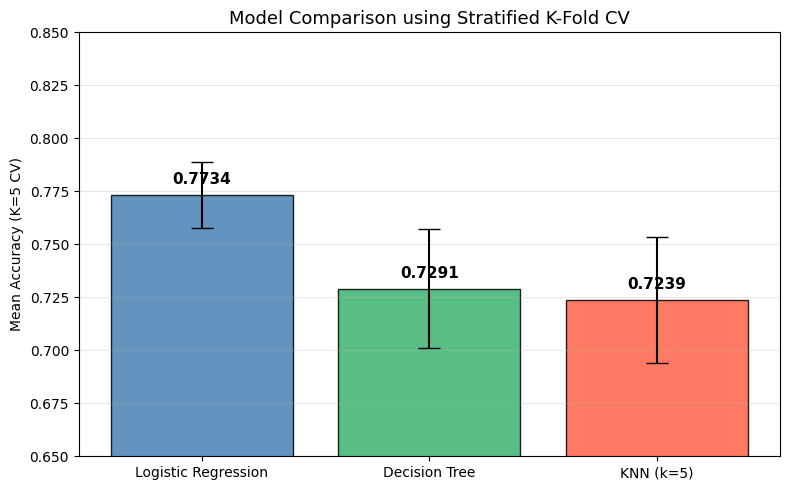

In [24]:
#  Bar chart comparing all 3 models

model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds  = [results[m].std()  for m in model_names]
colors = ['steelblue', 'mediumseagreen', 'tomato']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, means, yerr=stds, capsize=8,
               color=colors, edgecolor='black', alpha=0.85)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{mean:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.ylim([0.65, 0.85])
plt.ylabel("Mean Accuracy (K=5 CV)")
plt.title("Model Comparison using Stratified K-Fold CV", fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

   K    Mean Accuracy     Std Dev
-----------------------------------
K= 2  0.7643            0.0117
K= 3  0.7682            0.0157
K= 5  0.7734            0.0156
K=10  0.7668            0.0253
K=20  0.7694            0.0559


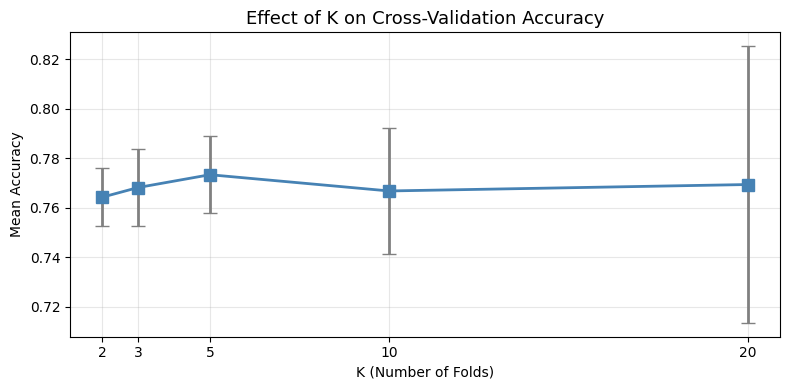

In [25]:
#  How does the number of folds (K) affect results?
# This is one of the key insights of your project

from sklearn.model_selection import StratifiedKFold

k_values = [2, 3, 5, 10, 20]
k_means = []
k_stds  = []

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

print(f"{'K':>4}  {'Mean Accuracy':>15}  {'Std Dev':>10}")
print("-" * 35)

for k in k_values:
    skf_k = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(pipeline, X, y, cv=skf_k, scoring='accuracy')
    k_means.append(s.mean())
    k_stds.append(s.std())
    print(f"K={k:>2}  {s.mean():.4f}            {s.std():.4f}")

plt.figure(figsize=(8, 4))
plt.errorbar(k_values, k_means, yerr=k_stds, marker='s', linewidth=2,
             markersize=9, color='steelblue', ecolor='gray', capsize=5)
plt.xlabel("K (Number of Folds)")
plt.ylabel("Mean Accuracy")
plt.title("Effect of K on Cross-Validation Accuracy", fontsize=13)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Print a clean final summary of your project
"""Key Takeaways:1. Single split gave accuracy ranging {min(scores_list):.4f}–{max(scores_list):.4f}
      → unreliable, depends on luck of the split
   2. K-Fold gives a stable mean ± confidence interval
   3. Stratified K-Fold is essential for imbalanced data
   4. In healthcare, Recall > Accuracy (avoid missed cases)
   5. K=5 or K=10 is the sweet spot for most datasets"""

print("     FINAL SUMMARY — K-FOLD CV ON DIABETES DATASET")

print(f"\n Model Results:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    s = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    print(f"   {name:<25}: {s.mean():.4f} ± {s.std():.4f}")


     FINAL SUMMARY — K-FOLD CV ON DIABETES DATASET

 Model Results:
   Logistic Regression      : 0.7734 ± 0.0156
   Decision Tree            : 0.7291 ± 0.0281
   KNN (k=5)                : 0.7239 ± 0.0297
